In [2]:
#!/usr/bin/env python
# coding: utf-8

# U-NET TRAINING - v6
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast
from tqdm import tqdm
import os
import gc

from unet3d import UNet3D
from luna16_dataset_and_dataloader import create_patch_dataloaders

gc.collect()
torch.cuda.empty_cache()
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# LOSS FUNCTIONS
class FocalLoss(nn.Module):
    """
    Focal loss down-weights easy (well-classified) voxels so training focuses
    on the hard ones — the nodule boundary and small nodules.
    alpha=0.5 : equal weight to positive/negative (BCE pos_weight handles
                 the class imbalance separately)
    gamma=2.0 : standard value from the original Focal Loss paper; reduces
                 the loss contribution of easy examples by ~4x
    """
    def __init__(self, alpha=0.5, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        bce = nn.BCEWithLogitsLoss(reduction='none')(inputs, targets)
        pt  = torch.exp(-bce)
        return torch.mean(self.alpha * (1 - pt) ** self.gamma * bce)


class DiceLoss(nn.Module):
    """
    Dice loss directly optimises the overlap between prediction and ground
    truth — the same metric we care about clinically.  BCE alone optimises
    per-voxel accuracy, which ignores the class imbalance (nodule voxels are
    <1% of a 96³ patch).  Dice is overlap-based so it is naturally balanced.
    smooth=1e-6 : tiny constant to avoid division by zero on empty masks
    """
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, predict, target):
        predict = torch.sigmoid(predict).view(-1)
        target  = target.view(-1)
        intersection = (predict * target).sum()
        return 1 - (2. * intersection + self.smooth) / (
            predict.sum() + target.sum() + self.smooth
        )


def combined_loss(pred, target, pos_weight_val: float, label_smoothing: float = 0.0):
    """
    0.5 * BCE(weighted) + 0.2 * Focal + 0.3 * Dice

    Why this mix:
      BCE  gives stable gradients and handles the pos_weight imbalance correction
      Focal stops easy negatives from dominating once the model is partly trained
      Dice directly optimises the overlap score we report

    label_smoothing only applied to BCE and Focal — NOT Dice.
    Dice measures overlap so it must see the original hard 0/1 targets to
    remain meaningful as a geometric metric.  Smoothing Dice targets would
    distort what "intersection" and "union" mean.
    """
    pos_weight = torch.tensor([pos_weight_val], device=pred.device)

    if label_smoothing > 0:
        smooth_target = target * (1 - label_smoothing) + 0.5 * label_smoothing
        bce   = nn.BCEWithLogitsLoss(pos_weight=pos_weight)(pred, smooth_target)
        focal = FocalLoss(alpha=0.5, gamma=2.0)(pred, smooth_target)
    else:
        bce   = nn.BCEWithLogitsLoss(pos_weight=pos_weight)(pred, target)
        focal = FocalLoss(alpha=0.5, gamma=2.0)(pred, target)

    dice = DiceLoss()(pred, target)   # always uses original hard targets
    return 0.5 * bce + 0.2 * focal + 0.3 * dice


# METRICS
def calculate_batch_metrics(predictions, targets, threshold=0.5):
    binary = (torch.sigmoid(predictions) > threshold).float().view(-1)
    tgt    = targets.view(-1)
    TP = ((binary == 1) & (tgt == 1)).sum().float()
    FP = ((binary == 1) & (tgt == 0)).sum().float()
    FN = ((binary == 0) & (tgt == 1)).sum().float()
    TN = ((binary == 0) & (tgt == 0)).sum().float()
    recall    = TP / (TP + FN + 1e-8)
    precision = TP / (TP + FP + 1e-8)
    dice      = (2 * TP) / (2 * TP + FP + FN + 1e-8)
    return {
        'TP': TP.item(), 'FP': FP.item(), 'FN': FN.item(), 'TN': TN.item(),
        'recall': recall.item(), 'precision': precision.item(), 'dice': dice.item(),
    }


# CONFIGURATION
# All tunable params are here with an explanation of what each one does
# and why this specific value was chosen for LUNA16 nodule segmentation.

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# paths 
PATCH_DIR = "/home/jovyan/vol.2/unet_patches"

# data 
BATCH_SIZE = 4

POSITIVE_FRACTION = 0.7
# extract_patches.py saved 90% positive patches.  The sampler corrects this
# down to 70/30 during training.  Change by editing this one number —
# no re-extraction needed.

NUM_WORKERS = 2

# model
INIT_FEATURES = 48
# Controls the width of the network.  48 → channels go 48,96,192,384,768
# across encoder stages.  Standard for LUNA16; larger = better but more VRAM.

DROPOUT = 0.2
# Dropout regularises the model.  0.2 is enough because AdamW weight_decay
# already provides regularisation.  v5 used 0.3 (SGD has no weight decay in
# the update rule itself, so it needed more dropout).

# AdamW optimizer
INITIAL_LR   = 1e-4
# AdamW standard starting point for 3-D medical image segmentation.
# SGD needed 1e-3 because it has no adaptive per-parameter scaling.
# AdamW adapts each weight's LR individually so it converges faster
# from a lower global LR.

WEIGHT_DECAY = 1e-5
# L2 penalty on the weights, applied in a decoupled way by AdamW (unlike
# vanilla Adam where weight decay interferes with the adaptive LR).
# 1e-5 is a light touch — enough to prevent large weights without
# slowing learning on sparse nodule voxels.

BETAS = (0.9, 0.999)
# β1=0.9  : momentum on the gradient (how much past gradients matter)
# β2=0.999: momentum on the squared gradient (used to normalise the step size)
# These are the original Adam paper defaults

EPS = 1e-8
# Small constant that prevents division by zero in the AdamW update rule.
# 1e-8 is the standard value.

# scheduler: CosineAnnealingWarmRestarts 
T_0    = 15
# Length of the first cosine cycle in epochs.  LR starts at INITIAL_LR,
# decays to ETA_MIN over 15 epochs, then restarts.
# Cycle lengths with T_MULT=2: 15 30 60 epochs.

T_MULT = 2
# Each restart cycle is T_MULT × longer than the previous one. Early restarts explore broadly;
# later long cycles refine the best region found.

ETA_MIN = 1e-6
# The LR floor at the bottom of each cosine cycle.  1e-6 is low enough
# that the model is effectively "cooling down" at the end of each cycle
# without completely stopping learning.

# loss 
POS_WEIGHT = 5.0
# Multiplies the BCE loss for positive (nodule) voxels.  Compensates for
# the fact that nodule voxels are a tiny fraction of each 96³ patch.

LABEL_SMOOTHING = 0.0
# Set to 0.0 to disable.

# gradient accumulation 
ACCUM_STEPS = 4
# Gradients are accumulated over 4 batches before an optimizer step.
# Set to 1 to disable accumulation.

# mixed precision (AMP) 
USE_AMP = True
# Automatic Mixed Precision runs forward pass in float16 and keeps a float32
# master copy for the optimizer step.  Typically 1.5–2× faster on modern
# GPUs and halves activation memory — important for 96³ patches.
# GradScaler prevents float16 underflow in the backward pass.

# gradient clipping 
GRAD_CLIP = 1.0
# Clips the global gradient norm to 1.0 before each optimizer step.
# Prevents exploding gradients, which can occur early in training when
# the model is far from a good solution.  1.0 is the standard value.

# training loop 
NUM_EPOCHS              = 60
EARLY_STOPPING_PATIENCE = 25

os.makedirs('./checkpoints/all_epochs', exist_ok=True)

print("=" * 65)
print("U-NET TRAINING  v6")
print("=" * 65)
print(f"  patch_dir        : {PATCH_DIR}")
print(f"  patch_size       : (96, 96, 96)")
print(f"  batch_size       : {BATCH_SIZE}  (effective {BATCH_SIZE*ACCUM_STEPS} with accum)")
print(f"  optimizer        : AdamW  lr={INITIAL_LR}  wd={WEIGHT_DECAY}  eps={EPS}")
print(f"  betas            : {BETAS}")
print(f"  scheduler        : CosineWarmRestarts  T0={T_0}  Tmult={T_MULT}  eta_min={ETA_MIN}")
print(f"  pos_weight       : {POS_WEIGHT}")
print(f"  label_smoothing  : {LABEL_SMOOTHING}")
print(f"  dropout          : {DROPOUT}")
print(f"  mixed precision  : {USE_AMP}")
print(f"  epochs           : {NUM_EPOCHS}")
print("=" * 65)



# DATA

print("\nLoading datasets...")
train_loader, val_loader, test_loader = create_patch_dataloaders(
    patch_dir=PATCH_DIR,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    positive_fraction=POSITIVE_FRACTION,
)


# MODEL

model = UNet3D(
    input_channels=1,
    output_channels=1,
    init_features=INIT_FEATURES,
    dropout=DROPOUT,
    checkpointing=False,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel params: {n_params/1e6:.2f}M  |  device: {device}")


# OPTIMIZER, SCHEDULER, AMP SCALER

optimizer = optim.AdamW(
    model.parameters(),
    lr=INITIAL_LR,
    betas=BETAS,
    eps=EPS,
    weight_decay=WEIGHT_DECAY,
)

scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=T_0,
    T_mult=T_MULT,
    eta_min=ETA_MIN,
)

scaler = GradScaler(enabled=USE_AMP)



# TRAINING LOOP

# RESUME FROM CHECKPOINT
RESUME_FROM = './checkpoints/last_checkpoint.pth'
start_epoch = 0

if os.path.exists(RESUME_FROM):
    print(f"\nResuming from checkpoint: {RESUME_FROM}")
    checkpoint = torch.load(RESUME_FROM, map_location=device)
    
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    scaler.load_state_dict(checkpoint['scaler_state_dict'])
    
    start_epoch            = checkpoint['epoch']  # already-completed epochs
    best_val_recall        = checkpoint['best_val_recall']
    best_balanced_dice     = checkpoint['best_balanced_dice']
    
    # Restore history lists so plots/summaries stay continuous
    train_losses      = checkpoint['train_losses']
    val_losses        = checkpoint['val_losses']
    train_recalls     = checkpoint['train_recalls']
    val_recalls       = checkpoint['val_recalls']
    train_precisions  = checkpoint['train_precisions']
    val_precisions    = checkpoint['val_precisions']
    train_dices       = checkpoint['train_dices']
    val_dices         = checkpoint['val_dices']
    learning_rates    = checkpoint['learning_rates']
    
    # Recompute early-stopping streak from restored history
    epochs_no_improve = 0
    for r in reversed(val_recalls):
        if r < best_val_recall:
            epochs_no_improve += 1
        else:
            break
    
    print(f"  Resumed at epoch {start_epoch + 1}  |  best_dice={best_balanced_dice:.4f}  best_recall={best_val_recall:.4f}")
    print(f"  No-improve streak restored: {epochs_no_improve}")
else:
    print("\nNo checkpoint found — starting fresh.")
    best_val_recall    = 0.0
    best_balanced_dice = 0.0
    epochs_no_improve  = 0

    train_losses, val_losses         = [], []
    train_recalls, val_recalls       = [], []
    train_precisions, val_precisions = [], []
    train_dices, val_dices           = [], []
    learning_rates                   = []

print("\nSTARTING TRAINING\n")

for epoch in range(start_epoch, NUM_EPOCHS):

    #TRAIN 
    model.train()
    train_loss = 0.0
    train_TP = train_FP = train_FN = train_TN = 0.0

    current_lr = optimizer.param_groups[0]['lr']
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train] lr={current_lr:.2e}")

    optimizer.zero_grad()

    for step, batch in enumerate(pbar):
        scans = batch['scan'].to(device, non_blocking=True)
        masks = batch['mask'].to(device, non_blocking=True)

        with autocast(enabled=USE_AMP):
            outputs = model(scans)
            loss = combined_loss(outputs, masks, POS_WEIGHT, LABEL_SMOOTHING) / ACCUM_STEPS

        scaler.scale(loss).backward()

        if (step + 1) % ACCUM_STEPS == 0 or (step + 1) == len(train_loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        train_loss += loss.item() * ACCUM_STEPS

        with torch.no_grad():
            m = calculate_batch_metrics(outputs, masks)
            train_TP += m['TP'];  train_FP += m['FP']
            train_FN += m['FN'];  train_TN += m['TN']

        pbar.set_postfix({'loss': f"{loss.item() * ACCUM_STEPS:.4f}"})

    avg_train_loss  = train_loss / len(train_loader)
    train_recall    = train_TP / (train_TP + train_FN + 1e-8)
    train_precision = train_TP / (train_TP + train_FP + 1e-8)
    train_dice      = (2 * train_TP) / (2 * train_TP + train_FP + train_FN + 1e-8)

    # VALIDATE 
    model.eval()
    val_loss = 0.0
    val_TP = val_FP = val_FN = val_TN = 0.0

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Val]  "):
            scans   = batch['scan'].to(device, non_blocking=True)
            masks   = batch['mask'].to(device, non_blocking=True)
            with autocast(enabled=USE_AMP):
                outputs = model(scans)
                val_loss += combined_loss(outputs, masks, POS_WEIGHT, LABEL_SMOOTHING).item()
            m = calculate_batch_metrics(outputs, masks)
            val_TP += m['TP'];  val_FP += m['FP']
            val_FN += m['FN'];  val_TN += m['TN']

    avg_val_loss  = val_loss / len(val_loader)
    val_recall    = val_TP / (val_TP + val_FN + 1e-8)
    val_precision = val_TP / (val_TP + val_FP + 1e-8)
    val_dice      = (2 * val_TP) / (2 * val_TP + val_FP + val_FN + 1e-8)

    # SCHEDULER STEP 
    scheduler.step(epoch + 1)
    new_lr = optimizer.param_groups[0]['lr']

    # RECORD
    train_losses.append(avg_train_loss);       val_losses.append(avg_val_loss)
    train_recalls.append(train_recall);        val_recalls.append(val_recall)
    train_precisions.append(train_precision);  val_precisions.append(val_precision)
    train_dices.append(train_dice);            val_dices.append(val_dice)
    learning_rates.append(current_lr)

    # PRINT SUMMARY
    print(f"\nEPOCH {epoch+1}/{NUM_EPOCHS}")
    print(f"  {'Metric':<12} {'Train':>10} {'Val':>10} {'Δ':>10}")
    print(f"  {'Loss':<12} {avg_train_loss:>10.4f} {avg_val_loss:>10.4f} {avg_val_loss-avg_train_loss:>+10.4f}")
    print(f"  {'Recall':<12} {train_recall:>10.4f} {val_recall:>10.4f} {val_recall-train_recall:>+10.4f}")
    print(f"  {'Precision':<12} {train_precision:>10.4f} {val_precision:>10.4f} {val_precision-train_precision:>+10.4f}")
    print(f"  {'Dice':<12} {train_dice:>10.4f} {val_dice:>10.4f} {val_dice-train_dice:>+10.4f}")
    print(f"  LR: {current_lr:.2e} → {new_lr:.2e}")

    if torch.cuda.is_available():
        alloc = torch.cuda.memory_allocated() / 1e9
        resv  = torch.cuda.memory_reserved()  / 1e9
        print(f"  GPU: {alloc:.1f}GB alloc / {resv:.1f}GB reserved")
        if resv > 20:
            print(f" High GPU memory ({resv:.1f}GB)")
        torch.cuda.reset_peak_memory_stats()

    # CHECKPOINTING 
    checkpoint = {
        'epoch': epoch + 1,
        'model_state_dict':     model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'scaler_state_dict':    scaler.state_dict(),
        'train_losses': train_losses,         'val_losses': val_losses,
        'train_recalls': train_recalls,       'val_recalls': val_recalls,
        'train_precisions': train_precisions, 'val_precisions': val_precisions,
        'train_dices': train_dices,           'val_dices': val_dices,
        'learning_rates': learning_rates,
        'best_val_recall': best_val_recall,
        'best_balanced_dice': best_balanced_dice,
        'config': {
            'batch_size': BATCH_SIZE,
            'accum_steps': ACCUM_STEPS,
            'effective_batch': BATCH_SIZE * ACCUM_STEPS,
            'optimizer': 'AdamW',
            'initial_lr': INITIAL_LR,
            'weight_decay': WEIGHT_DECAY,
            'betas': BETAS,
            'eps': EPS,
            'scheduler': 'CosineAnnealingWarmRestarts',
            'T_0': T_0, 'T_mult': T_MULT, 'eta_min': ETA_MIN,
            'pos_weight': POS_WEIGHT,
            'label_smoothing': LABEL_SMOOTHING,
            'dropout': DROPOUT,
            'patch_size': (96, 96, 96),
            'patch_dir': PATCH_DIR,
            'amp': USE_AMP,
            'device': str(device),
        },
    }

    torch.save(checkpoint, f'./checkpoints/all_epochs/epoch_{epoch+1:02d}.pth')
    torch.save(checkpoint, './checkpoints/last_checkpoint.pth')

    # EARLY STOPPING
    # Track val_recall improvement — U-Net is recall-maximising;
    # FP reduction is handled downstream by ResNet.
    if val_recall > best_val_recall:
        best_val_recall = val_recall
        epochs_no_improve = 0
        torch.save(checkpoint, './checkpoints/best_recall.pth')
        print(f"  ✓ Best recall: {val_recall:.4f}  (dice={val_dice:.4f}  precision={val_precision:.4f})")

        # Save separately if recall hits the target
        if val_recall >= 0.95:
            torch.save(checkpoint, './checkpoints/best_balanced.pth')
            print(f"  ★ TARGET HIT  recall={val_recall:.4f}  precision={val_precision:.4f}  dice={val_dice:.4f}")
    else:
        epochs_no_improve += 1

    print(f"  No-improve streak: {epochs_no_improve}/{EARLY_STOPPING_PATIENCE}")

    if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
        print(f"\nEARLY STOPPING after {epoch+1} epochs.")
        break



# FINAL SUMMARY
print("\n" + "=" * 65)
print("TRAINING COMPLETE")
print(f"  Best recall        : {best_val_recall:.4f}")
print(f"  Best balanced dice : {best_balanced_dice:.4f}")
if best_balanced_dice > 0:
    best_idx = val_dices.index(best_balanced_dice)
    print(f"  Best epoch         : {best_idx + 1}")
    print(f"    recall    = {val_recalls[best_idx]:.4f}")
    print(f"    precision = {val_precisions[best_idx]:.4f}")
    print(f"    dice      = {val_dices[best_idx]:.4f}")
print(f"\nCheckpoints saved in: ./checkpoints/")
print(f"  best_recall.pth    – highest val recall")
print(f"  best_balanced.pth  – 85–92% recall + best Dice")
print(f"  last_checkpoint.pth")
print("=" * 65)

U-NET TRAINING  v6
  patch_dir        : /home/jovyan/vol.2/unet_patches
  patch_size       : (96, 96, 96)
  batch_size       : 4  (effective 16 with accum)
  optimizer        : AdamW  lr=0.0001  wd=1e-05  eps=1e-08
  betas            : (0.9, 0.999)
  scheduler        : CosineWarmRestarts  T0=15  Tmult=2  eta_min=1e-06
  pos_weight       : 5.0
  label_smoothing  : 0.0
  dropout          : 0.2
  mixed precision  : True
  epochs           : 60

Loading datasets...
  TRAIN: 49518 patches  | 30168 positive  | 19350 negative
  VAL  : 6880 patches  | 4392 positive  | 2488 negative
  TEST : 14640 patches  | 8712 positive  | 5928 negative

  Loaders | batch=4 | workers=2 | pos_fraction=0.7
  train=12380 batches | val=1720 | test=3660

Model params: 51.98M  |  device: cuda

Resuming from checkpoint: ./checkpoints/last_checkpoint.pth


/tmp/ipykernel_16474/3729734857.py:281: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USE_AMP)


  Resumed at epoch 53  |  best_dice=0.8231  best_recall=0.8536
  No-improve streak restored: 16

STARTING TRAINING



Epoch 53/60 [Train] lr=9.67e-05:   0%|          | 0/12380 [00:00<?, ?it/s]/tmp/ipykernel_16474/3729734857.py:355: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):
Epoch 53/60 [Val]  :   0%|          | 0/1720 [00:00<?, ?it/s]/tmp/ipykernel_16474/3729734857.py:391: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):
Epoch 53/60 [Val]  : 100%|██████████| 1720/1720 [04:07<00:00,  6.95it/s]



EPOCH 53/60
  Metric            Train        Val          Δ
  Loss             0.0558     0.1570    +0.1012
  Recall           0.8721     0.7804    -0.0918
  Precision        0.8666     0.8218    -0.0447
  Dice             0.8693     0.8006    -0.0688
  LR: 9.67e-05 → 9.57e-05
  GPU: 0.9GB alloc / 19.3GB reserved
  No-improve streak: 17/25


...


EPOCH 58/60
  Metric            Train        Val          Δ
  Loss             0.0521     0.1551    +0.1030
  Recall           0.8795     0.8246    -0.0549
  Precision        0.8777     0.8074    -0.0703
  Dice             0.8786     0.8159    -0.0627
  LR: 9.05e-05 → 8.90e-05
  GPU: 0.7GB alloc / 19.3GB reserved
  No-improve streak: 22/25


Epoch 59/60 [Val]  : 100%|██████████| 1720/1720 [04:07<00:00,  6.94it/s]



EPOCH 59/60
  Metric            Train        Val          Δ
  Loss             0.0512     0.1544    +0.1032
  Recall           0.8839     0.8220    -0.0619
  Precision        0.8787     0.8329    -0.0459
  Dice             0.8813     0.8274    -0.0539
  LR: 8.90e-05 → 8.73e-05
  GPU: 0.7GB alloc / 19.3GB reserved
  No-improve streak: 23/25


Epoch 60/60 [Val]  : 100%|██████████| 1720/1720 [04:07<00:00,  6.95it/s]



EPOCH 60/60
  Metric            Train        Val          Δ
  Loss             0.0506     0.1547    +0.1041
  Recall           0.8868     0.8243    -0.0624
  Precision        0.8804     0.8115    -0.0690
  Dice             0.8836     0.8178    -0.0657
  LR: 8.73e-05 → 8.55e-05
  GPU: 0.7GB alloc / 19.3GB reserved
  No-improve streak: 24/25

TRAINING COMPLETE
  Best recall        : 0.8536
  Best balanced dice : 0.8231
  Best epoch         : 37
    recall    = 0.8329
    precision = 0.8136
    dice      = 0.8231

Checkpoints saved in: ./checkpoints/
  best_recall.pth    – highest val recall
  best_balanced.pth  – 85–92% recall + best Dice
  last_checkpoint.pth


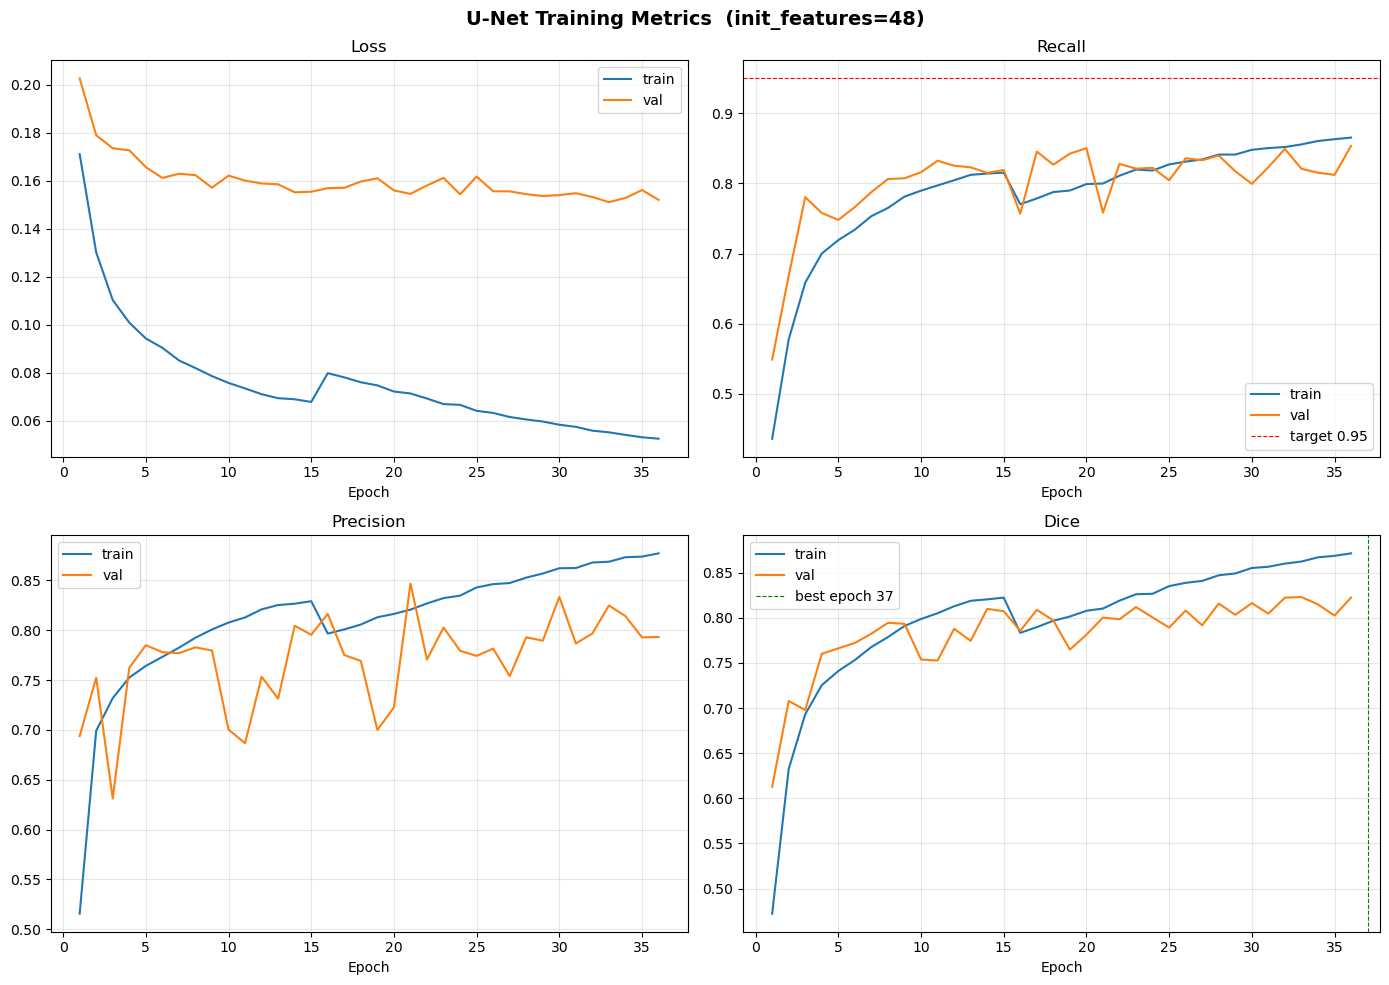

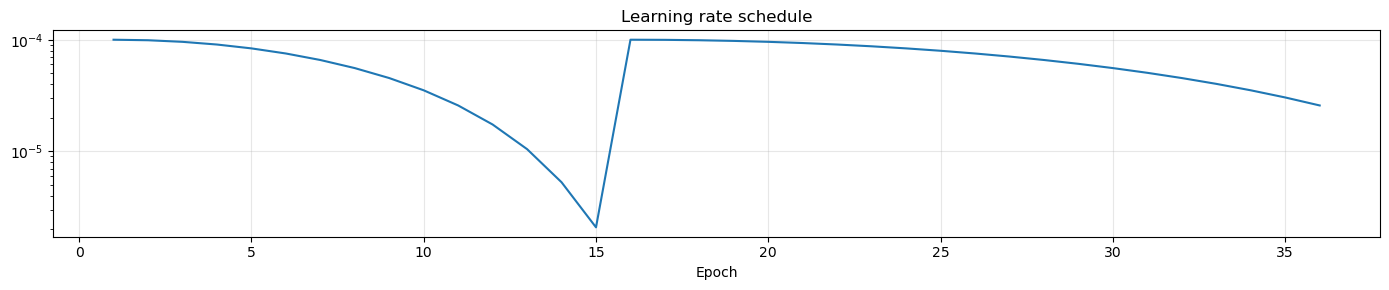

Saved: training_metrics.png, lr_schedule.png


In [3]:
import torch
import matplotlib.pyplot as plt

checkpoint = torch.load('./checkpoints/best_recall.pth', map_location='cpu')

epochs = range(1, len(checkpoint['train_losses']) + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('U-Net Training Metrics  (init_features=48)', fontsize=14, fontweight='bold')

# Loss
axes[0,0].plot(epochs, checkpoint['train_losses'], label='train')
axes[0,0].plot(epochs, checkpoint['val_losses'],   label='val')
axes[0,0].set_title('Loss');  axes[0,0].set_xlabel('Epoch')
axes[0,0].legend();           axes[0,0].grid(alpha=0.3)

# Recall
axes[0,1].plot(epochs, checkpoint['train_recalls'], label='train')
axes[0,1].plot(epochs, checkpoint['val_recalls'],   label='val')
axes[0,1].axhline(0.95, color='red', linestyle='--', linewidth=0.8, label='target 0.95')
axes[0,1].set_title('Recall'); axes[0,1].set_xlabel('Epoch')
axes[0,1].legend();             axes[0,1].grid(alpha=0.3)

# Precision
axes[1,0].plot(epochs, checkpoint['train_precisions'], label='train')
axes[1,0].plot(epochs, checkpoint['val_precisions'],   label='val')
axes[1,0].set_title('Precision'); axes[1,0].set_xlabel('Epoch')
axes[1,0].legend();               axes[1,0].grid(alpha=0.3)

# Dice
axes[1,1].plot(epochs, checkpoint['train_dices'], label='train')
axes[1,1].plot(epochs, checkpoint['val_dices'],   label='val')
axes[1,1].axvline(37, color='green', linestyle='--', linewidth=0.8, label='best epoch 37')
axes[1,1].set_title('Dice'); axes[1,1].set_xlabel('Epoch')
axes[1,1].legend();          axes[1,1].grid(alpha=0.3)

# Learning rate as a bonus
fig2, ax = plt.subplots(figsize=(14, 3))
ax.plot(epochs, checkpoint['learning_rates'])
ax.set_title('Learning rate schedule')
ax.set_xlabel('Epoch'); ax.set_yscale('log'); ax.grid(alpha=0.3)
fig2.tight_layout()

fig.tight_layout()
plt.savefig('training_metrics.png', dpi=150, bbox_inches='tight')
plt.savefig('lr_schedule.png',      dpi=150, bbox_inches='tight')
plt.show()
print("Saved: training_metrics.png, lr_schedule.png")

In [1]:
import torch
from unet3d import UNet3D
from luna16_dataset_and_dataloader import create_patch_dataloaders
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

checkpoint = torch.load('./checkpoints/best_recall.pth', map_location=device)
model = UNet3D(input_channels=1, output_channels=1, init_features=48, dropout=0.2, checkpointing=False).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

_, val_loader, _ = create_patch_dataloaders(
    patch_dir="/home/jovyan/vol.2/unet_patches",
    batch_size=4, num_workers=2, positive_fraction=0.7,
)

thresholds = [t/100 for t in range(5, 55, 5)]
counts = {t: {'TP': 0, 'FP': 0, 'FN': 0} for t in thresholds}

print("Running model once...")
with torch.no_grad():
    for batch in tqdm(val_loader):
        scans = batch['scan'].to(device)
        masks = batch['mask'].to(device)
        probs = torch.sigmoid(model(scans))

        # compute counts for all thresholds on this batch, then discard probs
        for t in thresholds:
            binary = (probs > t).float().view(-1)
            tgt    = masks.view(-1)
            counts[t]['TP'] += ((binary == 1) & (tgt == 1)).sum().item()
            counts[t]['FP'] += ((binary == 1) & (tgt == 0)).sum().item()
            counts[t]['FN'] += ((binary == 0) & (tgt == 1)).sum().item()

        # probs and binary are discarded after each batch — no RAM buildup

print("\nDone.\n")
print(f"{'Threshold':>10} {'Recall':>10} {'Precision':>10} {'Dice':>10}")
print("-" * 44)

for t in thresholds:
    TP = counts[t]['TP']
    FP = counts[t]['FP']
    FN = counts[t]['FN']
    recall    = TP / (TP + FN + 1e-8)
    precision = TP / (TP + FP + 1e-8)
    dice      = (2 * TP) / (2 * TP + FP + FN + 1e-8)
    marker    = " ← target" if abs(recall - 0.95) < 0.03 else ""
    print(f"{t:>10.2f} {recall:>10.4f} {precision:>10.4f} {dice:>10.4f}{marker}")

  TRAIN: 49518 patches  | 30168 positive  | 19350 negative
  VAL  : 6880 patches  | 4392 positive  | 2488 negative
  TEST : 14640 patches  | 8712 positive  | 5928 negative

  Loaders | batch=4 | workers=2 | pos_fraction=0.7
  train=12380 batches | val=1720 | test=3660
Running model once...


100%|██████████| 1720/1720 [04:41<00:00,  6.11it/s]


Done.

 Threshold     Recall  Precision       Dice
--------------------------------------------
      0.05     0.8736     0.7679     0.8173
      0.10     0.8681     0.7753     0.8191
      0.15     0.8650     0.7795     0.8200
      0.20     0.8626     0.7825     0.8206
      0.25     0.8607     0.7849     0.8210
      0.30     0.8590     0.7869     0.8214
      0.35     0.8575     0.7887     0.8217
      0.40     0.8562     0.7903     0.8219
      0.45     0.8548     0.7918     0.8221
      0.50     0.8536     0.7933     0.8223


In [ ]:
import time

while True:
    print("still alive")
    time.sleep(60)

In [ ]:
import torch
checkpoint = torch.load('./checkpoints/last_checkpoint.pth', map_location='cpu')
print("Checkpoint loaded ok, epoch:", checkpoint['epoch'])

In [ ]:
import gc
import torch

# Force-free everything before starting
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

# Confirm GPU state
print(f"GPU memory before loading: {torch.cuda.memory_reserved()/1e9:.1f} GB reserved")

In [ ]:
import os
import torch

checkpoint_dir = './checkpoints'

# Check if directory exists and list contents
if os.path.exists(checkpoint_dir):
    for root, dirs, files in os.walk(checkpoint_dir):
        for f in files:
            full_path = os.path.join(root, f)
            size_mb = os.path.getsize(full_path) / 1e6
            print(f"{full_path}  ({size_mb:.1f} MB)")
else:
    print("Checkpoint directory not found!")

In [ ]:
ckpt = torch.load('./checkpoints/last_checkpoint.pth', map_location='cpu')
print("Epoch saved:", ckpt['epoch'])
print("Val dices:  ", ckpt['val_dices'])
print("Val recalls:", ckpt['val_recalls'])